# HBR Normal: MCMC vs VI

The same comparison as `04_HBR_SHASH_variational_inference_benchmark.ipynb`,
but with a **Normal** likelihood instead of SHASHb. The SHASH likelihood has
four parameters (mu, sigma, epsilon, delta); the Normal has two. If the
approximations struggle because the SHASH posterior is awkwardly shaped, they
should do better here.

| Method | What it does |
|---|---|
| `mcmc` | NUTS sampling via nutpie. The current default. Exact but slow. |
| `advi` | Mean-field variational inference. Optimises a Gaussian approximation. |
| `pathfinder` | Quasi-Newton variational inference (needs `pymc-extras`). |
| `laplace` | Gaussian centred on the posterior mode, covariance from the Hessian there (needs `pymc-extras`). |

This notebook stops after the posterior-width comparison.

## Imports

In [1]:
import logging
import time
import warnings

import numpy as np
import pandas as pd

import pcntoolkit.util.output
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    make_prior,
)

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pymc").propagate = False
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None
pcntoolkit.util.output.Output.set_show_messages(False)

from pcntoolkit import NormalLikelihood, load_fcon1000

## Load data

Same six response variables as the SHASH benchmark.

In [2]:
norm_data: NormData = load_fcon1000()
# Six response variables with different shapes: a skewed count-like measure,
# ventricles, subcortical volumes, a global volume and cortical thickness.
features_to_model = [
    "WM-hypointensities",
    "Right-Lateral-Ventricle",
    "Right-Amygdala",
    "Left-Hippocampus",
    "CortexVol",
    "lh_G_front_middle_thickness",
]
norm_data = norm_data.sel({"response_vars": features_to_model})
train, test = norm_data.train_test_split()
print(f"train observations: {train.X.shape[0]}")
print(f"response variables: {len(features_to_model)}")

train observations: 862
response variables: 6


## Model specification

`mu` and `sigma` keep the same structure as the SHASH benchmark - a B-spline
over age, a random intercept over sites and sexes for `mu` - so the only
difference between the two notebooks is the likelihood.

In [3]:
def make_normal_likelihood() -> NormalLikelihood:
    """Normal likelihood with the same mu/sigma structure as the SHASH benchmark."""
    mu = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
        intercept=make_prior(
            random=True,
            mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
            sigma=make_prior(
                dist_name="Normal",
                dist_params=(0.0, 1.0),
                mapping="softplus",
                mapping_params=(0.0, 3.0),
            ),
        ),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    )
    sigma = make_prior(
        linear=True,
        slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
        intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
        mapping="softplus",
        mapping_params=(0.0, 3.0),
    )
    return NormalLikelihood(mu, sigma)


def build_model(inference_method: str) -> NormativeModel:
    """Wrap the Normal HBR in a NormativeModel using the given inference method."""
    reg = HBR(
        name="template",
        cores=16,
        progressbar=False,
        draws=1500,
        tune=500,
        chains=4,
        nuts_sampler="nutpie",
        likelihood=make_normal_likelihood(),
        # The switch: "mcmc", "advi", "pathfinder" or "laplace".
        inference_method=inference_method,
        vi_iterations=30000,
        vi_draws=1000,
    )
    return NormativeModel(
        template_regression_model=reg,
        savemodel=False,
        evaluate_model=False,
        saveresults=False,
        saveplots=False,
        save_dir=f"resources/hbr_normal_bench/{inference_method}",
        inscaler="standardize",
        outscaler="standardize",
    )

## Run the benchmark

Fit one model with each inference method, and time each fit.

In [4]:
timings: dict[str, float] = {}
fits: dict[str, NormativeModel] = {}   # keep every fit for the accuracy checks later

METHODS = ["mcmc", "advi", "pathfinder", "laplace"]

for method in METHODS:
    print(f"=== {method} ===")
    try:
        m = build_model(method)
        t = time.time()
        m.fit(train)
        timings[method] = time.time() - t
        fits[method] = m
        print(f"  {method}: {timings[method]:.1f}s\n")
    except ImportError as e:
        print(f"  {method} SKIPPED: {e}\n")
    except Exception as e:
        print(f"  {method} FAILED: {type(e).__name__}: {e}\n")

=== mcmc ===


c:\Users\kontsi\AppData\Local\anaconda3\envs\ptk-vi\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


  mcmc: 177.7s

=== advi ===
  advi: 88.6s

=== pathfinder ===


Pathfinder Results                            
                                              
  No. model parameters     43                 
                                              
  Configuration:                              
  num_draws_per_path       1000               
  history size (maxcor)    12                 
  max iterations           1000               
  ftol                     1.00e-05           
  gtol                     1.00e-08           
  max line search          1000               
  jitter                   2.0                
  epsilon                  1.00e-12           
  ELBO draws               10                 
                                              
  LBFGS Status:                               
  CONVERGED                4                  
  L-BFGS iterations        mean 116 ± std 12  
                                              
  Path Status:                                
  SUCCESS                  4                  
  ELBO argmax              mean 82 ± std 31   
                                              
  Importance Sampling:                        
  Method                   psis               
  Pareto k                 1.82               
                                              
  Timing (seconds):                           
  Compile                  13.20              
  Compute                  22.44              
  Total                    35.64

Pathfinder Results                           
                                             
  No. model parameters     43                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 72 ± std 5   
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 35 ± std 13  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 2.02              
                                             
  Timing (seconds):                          
  Compile                  5.61              
  Compute                  21.74             
  Total                    27.34

Pathfinder Results                           
                                             
  No. model parameters     43                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 74 ± std 6   
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 42 ± std 12  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 1.97              
                                             
  Timing (seconds):                          
  Compile                  7.36              
  Compute                  21.32             
  Total                    28.69

Pathfinder Results                           
                                             
  No. model parameters     43                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 96 ± std 14  
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 54 ± std 18  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 2.21              
                                             
  Timing (seconds):                          
  Compile                  5.13              
  Compute                  20.00             
  Total                    25.13

Pathfinder Results                           
                                             
  No. model parameters     43                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 91 ± std 9   
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 61 ± std 22  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 2.05              
                                             
  Timing (seconds):                          
  Compile                  5.28              
  Compute                  19.62             
  Total                    24.90

Pathfinder Results                           
                                             
  No. model parameters     43                
                                             
  Configuration:                             
  num_draws_per_path       1000              
  history size (maxcor)    12                
  max iterations           1000              
  ftol                     1.00e-05          
  gtol                     1.00e-08          
  max line search          1000              
  jitter                   2.0               
  epsilon                  1.00e-12          
  ELBO draws               10                
                                             
  LBFGS Status:                              
  CONVERGED                4                 
  L-BFGS iterations        mean 94 ± std 15  
                                             
  Path Status:                               
  SUCCESS                  4                 
  ELBO argmax              mean 59 ± std 21  
                                             
  Importance Sampling:                       
  Method                   psis              
  Pareto k                 1.72              
                                             
  Timing (seconds):                          
  Compile                  5.31              
  Compute                  20.43             
  Total                    25.73

  pathfinder: 188.8s

=== laplace ===
  laplace: 38.2s



---

# Timing results

In [5]:
ref = timings.get("mcmc")
rows = []
for k, v in sorted(timings.items(), key=lambda kv: kv[1]):
    rows.append({
        "method": k,
        "fit time (s)": round(v, 1),
        "speedup vs mcmc": f"{ref / v:.1f}x" if ref else "n/a",
    })
pd.DataFrame(rows)

,method,fit time (s),speedup vs mcmc
0,laplace,38.2,4.6x
1,advi,88.6,2.0x
2,mcmc,177.7,1.0x
3,pathfinder,188.8,0.9x


---

# Accuracy results

1. **Z-scores** on held-out test data
2. **Centiles**
3. **Posterior width** - the diagnostic that explains errors in 1 and 2

## 1. Z-scores vs MCMC

`corr` should be as close to 1 as possible and `max|dz|` small (this shows if a
specific subject's z score diverged a lot from the reference MCMC).

In [6]:
CENTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
RESPONSE_VARS = [str(r) for r in features_to_model]

# Z-scores keyed by (method, response_var): predict() writes one column per
# response variable, so they must be kept apart rather than flattened together.
zs: dict[tuple[str, str], np.ndarray] = {}
for method, m in fits.items():
    td = test.copy()
    m.predict(td)
    for rv in RESPONSE_VARS:
        zs[(method, rv)] = np.asarray(td["Z"].sel(response_vars=rv).values).ravel()

others = [k for k in fits if k != "mcmc"]

rows = []
for rv in RESPONSE_VARS:
    zref_rv = zs[("mcmc", rv)]
    for method in others:
        z = zs[(method, rv)]
        d = np.abs(z - zref_rv)
        rows.append({
            "response_var": rv,
            "method": method,
            "corr": round(float(np.corrcoef(z, zref_rv)[0, 1]), 4),
            "max |dz|": round(float(d.max()), 4),
            "mean |dz|": round(float(d.mean()), 4),
            "sd ratio": round(float(z.std() / zref_rv.std()), 4),
        })

z_df = pd.DataFrame(rows)
print("mean over response variables:")
print(z_df.groupby("method")[["corr", "max |dz|", "mean |dz|", "sd ratio"]].mean().round(4))
z_df

mean over response variables:
              corr  max |dz|  mean |dz|  sd ratio
method                                           
advi        0.9996    0.1816     0.0197    0.9892
laplace     0.9995    0.3502     0.0256    1.0206
pathfinder  0.9990    0.2886     0.0313    1.0096


,response_var,method,corr,max |dz|,mean |dz|,sd ratio
0,WM-hypointensities,advi,0.9993,0.1486,0.0264,0.9823
1,WM-hypointensities,pathfinder,0.9994,0.1643,0.0220,1.0048
2,WM-hypointensities,laplace,0.9999,0.1160,0.0180,1.0202
3,Right-Lateral-Ventricle,advi,0.9998,0.0996,0.0167,0.9923
4,Right-Lateral-Ventricle,pathfinder,0.9989,0.4291,0.0325,1.0130
5,Right-Lateral-Ventricle,laplace,0.9996,0.4127,0.0234,1.0192
6,Right-Amygdala,advi,0.9997,0.1306,0.0196,0.9905
7,Right-Amygdala,pathfinder,0.9992,0.2339,0.0284,1.0078
8,Right-Amygdala,laplace,0.9996,0.1863,0.0270,1.0176
9,Left-Hippocampus,advi,0.9995,0.4750,0.0184,0.9893


### Plot

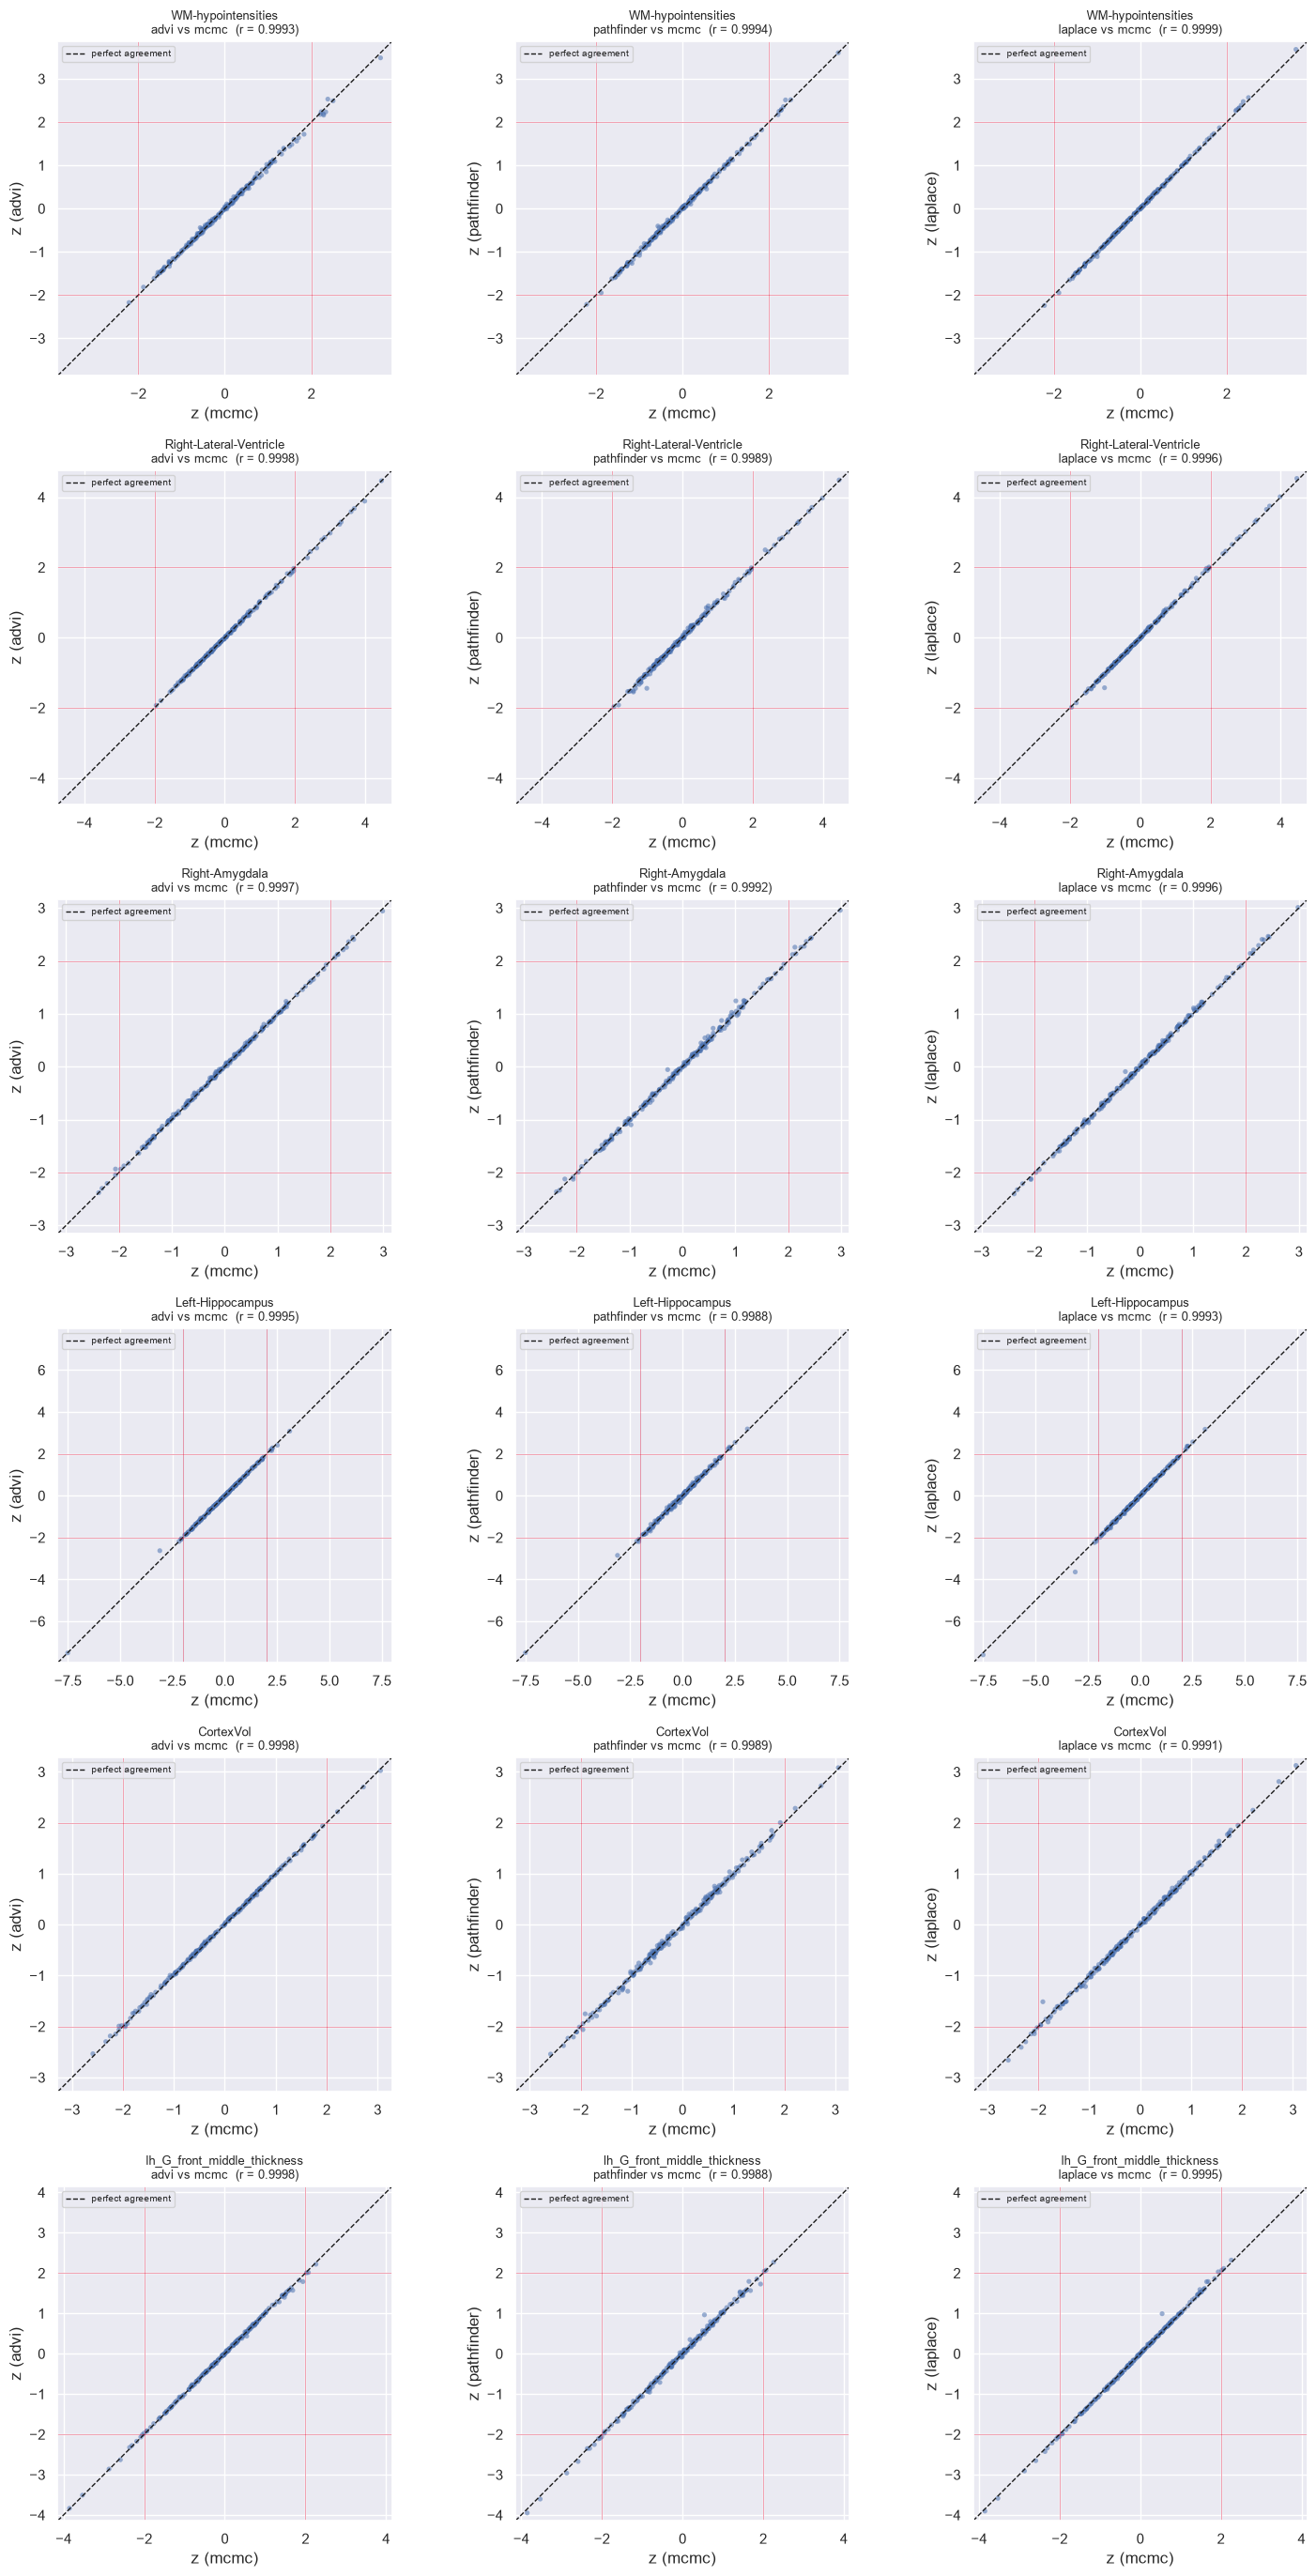

In [7]:
import matplotlib.pyplot as plt

# One row per response variable, one column per approximation.
fig, axes = plt.subplots(len(RESPONSE_VARS), len(others),
                         figsize=(5 * len(others), 4.6 * len(RESPONSE_VARS)),
                         squeeze=False)

for r, rv in enumerate(RESPONSE_VARS):
    zref_rv = zs[("mcmc", rv)]
    lim = float(np.abs(np.concatenate([zs[(m, rv)] for m in fits])).max()) * 1.05
    for c, method in enumerate(others):
        ax = axes[r][c]
        z = zs[(method, rv)]
        ax.scatter(zref_rv, z, s=14, alpha=0.55, edgecolor="none")
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="perfect agreement")
        # z = +-2 is the conventional outlier threshold.
        for t in (-2, 2):
            ax.axhline(t, color="crimson", lw=0.7, alpha=0.4)
            ax.axvline(t, color="crimson", lw=0.7, alpha=0.4)
        corr = np.corrcoef(z, zref_rv)[0, 1]
        ax.set_title(f"{rv}\n{method} vs mcmc  (r = {corr:.4f})", fontsize=9)
        ax.set_xlabel("z (mcmc)")
        ax.set_ylabel(f"z ({method})")
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")
        ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.show()

### Outlier detection

Subjects that cross the z = +-2 line between methods are the practical cost of
the approximation: same person, different outlier call.

In [8]:
THRESH = 2.0
rows = []
for rv in RESPONSE_VARS:
    zref_rv = zs[("mcmc", rv)]
    ref_out = np.abs(zref_rv) > THRESH
    for method in others:
        new_out = np.abs(zs[(method, rv)]) > THRESH
        rows.append({
            "response_var": rv,
            "method": method,
            f"outliers mcmc (|z|>{THRESH})": int(ref_out.sum()),
            "outliers approx": int(new_out.sum()),
            "disagreements": int((ref_out != new_out).sum()),
            "% of subjects": round(100 * float((ref_out != new_out).mean()), 2),
        })

out_df = pd.DataFrame(rows)
print("mean over response variables:")
print(out_df.groupby("method")[["disagreements", "% of subjects"]].mean().round(2))
out_df

mean over response variables:
            disagreements  % of subjects
method                                  
advi                 0.83           0.38
laplace              0.33           0.15
pathfinder           0.33           0.16


,response_var,method,outliers mcmc (|z|>2.0),outliers approx,disagreements,% of subjects
0,WM-hypointensities,advi,9,9,0,0.00
1,WM-hypointensities,pathfinder,9,9,0,0.00
2,WM-hypointensities,laplace,9,9,0,0.00
3,Right-Lateral-Ventricle,advi,12,12,0,0.00
4,Right-Lateral-Ventricle,pathfinder,12,12,0,0.00
5,Right-Lateral-Ventricle,laplace,12,13,1,0.46
6,Right-Amygdala,advi,14,13,1,0.46
7,Right-Amygdala,pathfinder,14,14,0,0.00
8,Right-Amygdala,laplace,14,14,0,0.00
9,Left-Hippocampus,advi,11,11,0,0.00


## 2. Centiles vs MCMC

Differences are shown as a percentage of each response variable's standard
deviation. To keep the comparison free of extrapolation we use the "inner" 95%
of subjects and exclude the 5% that lie in the sparse tails.

In [9]:
from pcntoolkit import NormData

ref_model = fits["mcmc"]
covariate = str(ref_model.covariates[0])
cov_min = ref_model.covariate_ranges[covariate]["min"]
cov_max = ref_model.covariate_ranges[covariate]["max"]
# Cast to plain str: batch effect keys come back as np.str_, which does not
# always compare equal to the column names downstream.
fixed_be = {
    str(k): str(max(v.items(), key=lambda x: x[1])[0])
    for k, v in ref_model.batch_effect_counts.items()
}
print(f"covariate: {covariate}   fixed batch effects: {fixed_be}")

grid_x = np.linspace(cov_min, cov_max, 150)
grid_df = pd.DataFrame({covariate: grid_x})
for cov in ref_model.covariates:
    if str(cov) != covariate:
        grid_df[str(cov)] = float(test.X.sel(covariates=cov).mean().values)
for be, v in fixed_be.items():
    grid_df[be] = v
for rv in ref_model.response_vars:
    grid_df[str(rv)] = 1e-6


def make_grid() -> NormData:
    """Fresh grid NormData (compute_centiles mutates its argument in place)."""
    return NormData.from_dataframe(
        "centile_grid",
        dataframe=grid_df.copy(),
        covariates=[str(c) for c in ref_model.covariates],
        response_vars=[str(r) for r in ref_model.response_vars],
        batch_effects=list(fixed_be.keys()),
    )


# centiles come back as (centile, grid point, response_var)
cents: dict[str, np.ndarray] = {}
grid_rvs: list[str] = []
for method, m in fits.items():
    gd = make_grid()
    m.compute_centiles(gd, centiles=CENTILES)
    cents[method] = np.asarray(gd["centiles"].values)
    grid_rvs = [str(r) for r in gd["centiles"].coords["response_vars"].values]

# Y sd per response variable, so centile errors are comparable across scales.
y_sds = {rv: float(np.nanstd(np.asarray(test.Y.sel(response_vars=rv).values).ravel()))
         for rv in RESPONSE_VARS}
cref = cents["mcmc"]

# To avoid extrapolation select the "inner" 95% of subjects and exclude
# the 5% of the subjects that lie on the sparse tails.
age_obs = np.asarray(test.X.values)[:, 0]
lo, hi = np.percentile(age_obs, [2.5, 97.5])
inner = (grid_x >= lo) & (grid_x <= hi)
print(f"comparing over {covariate} in [{lo:.1f}, {hi:.1f}] "
      f"({inner.sum()}/{len(grid_x)} grid points)")

rows = []
for method, c in cents.items():
    if method == "mcmc" or c.shape != cref.shape:
        continue
    for j, rv in enumerate(grid_rvs):
        y_sd_rv = y_sds[rv]
        d = np.abs(c[:, :, j] - cref[:, :, j])
        d_in = d[:, inner]
        imax = np.unravel_index(np.argmax(d_in), d_in.shape)
        rows.append({
            "response_var": rv,
            "method": method,
            "max % Y sd (all)": round(100 * float(d.max()) / y_sd_rv, 1),
            "max % Y sd (inner)": round(100 * float(d_in.max()) / y_sd_rv, 1),
            "mean % Y sd (inner)": round(100 * float(d_in.mean()) / y_sd_rv, 1),
            "median % Y sd (inner)": round(100 * float(np.median(d_in)) / y_sd_rv, 1),
            "worst centile": CENTILES[imax[0]],
            f"worst {covariate}": round(float(grid_x[inner][imax[1]]), 1),
        })

cent_df = pd.DataFrame(rows)
print("\nmean over response variables:")
print(cent_df.groupby("method")[["max % Y sd (inner)", "mean % Y sd (inner)"]].mean().round(1))
cent_df

covariate: age   fixed batch effects: {'sex': 'F', 'site': 'Beijing_Zang'}
comparing over age in [18.0, 66.6] (94/150 grid points)

mean over response variables:
            max % Y sd (inner)  mean % Y sd (inner)
method                                             
advi                      13.1                  3.1
laplace                   10.7                  2.7
pathfinder                13.7                  4.9


,response_var,method,max % Y sd (all),max % Y sd (inner),mean % Y sd (inner),median % Y sd (inner),worst centile,worst age
0,WM-hypointensities,advi,191.4,33.0,5.9,4.0,0.95,64.3
1,Right-Lateral-Ventricle,advi,61.0,12.7,3.1,2.7,0.05,66.4
2,Right-Amygdala,advi,36.9,6.6,2.5,2.3,0.05,58.6
3,Left-Hippocampus,advi,36.7,6.2,2.1,2.1,0.95,66.4
4,CortexVol,advi,35.6,5.7,2.1,2.0,0.05,66.4
5,lh_G_front_middle_thickness,advi,35.2,14.2,3.0,1.9,0.05,65.8
6,WM-hypointensities,pathfinder,414.5,14.1,4.9,3.0,0.95,61.2
7,Right-Lateral-Ventricle,pathfinder,116.6,9.5,3.6,3.4,0.95,38.4
8,Right-Amygdala,pathfinder,77.8,6.9,3.6,3.6,0.05,32.7
9,Left-Hippocampus,pathfinder,89.2,21.1,8.0,7.5,0.05,62.2


### Plot

Solid = MCMC, dashed = the approximation.

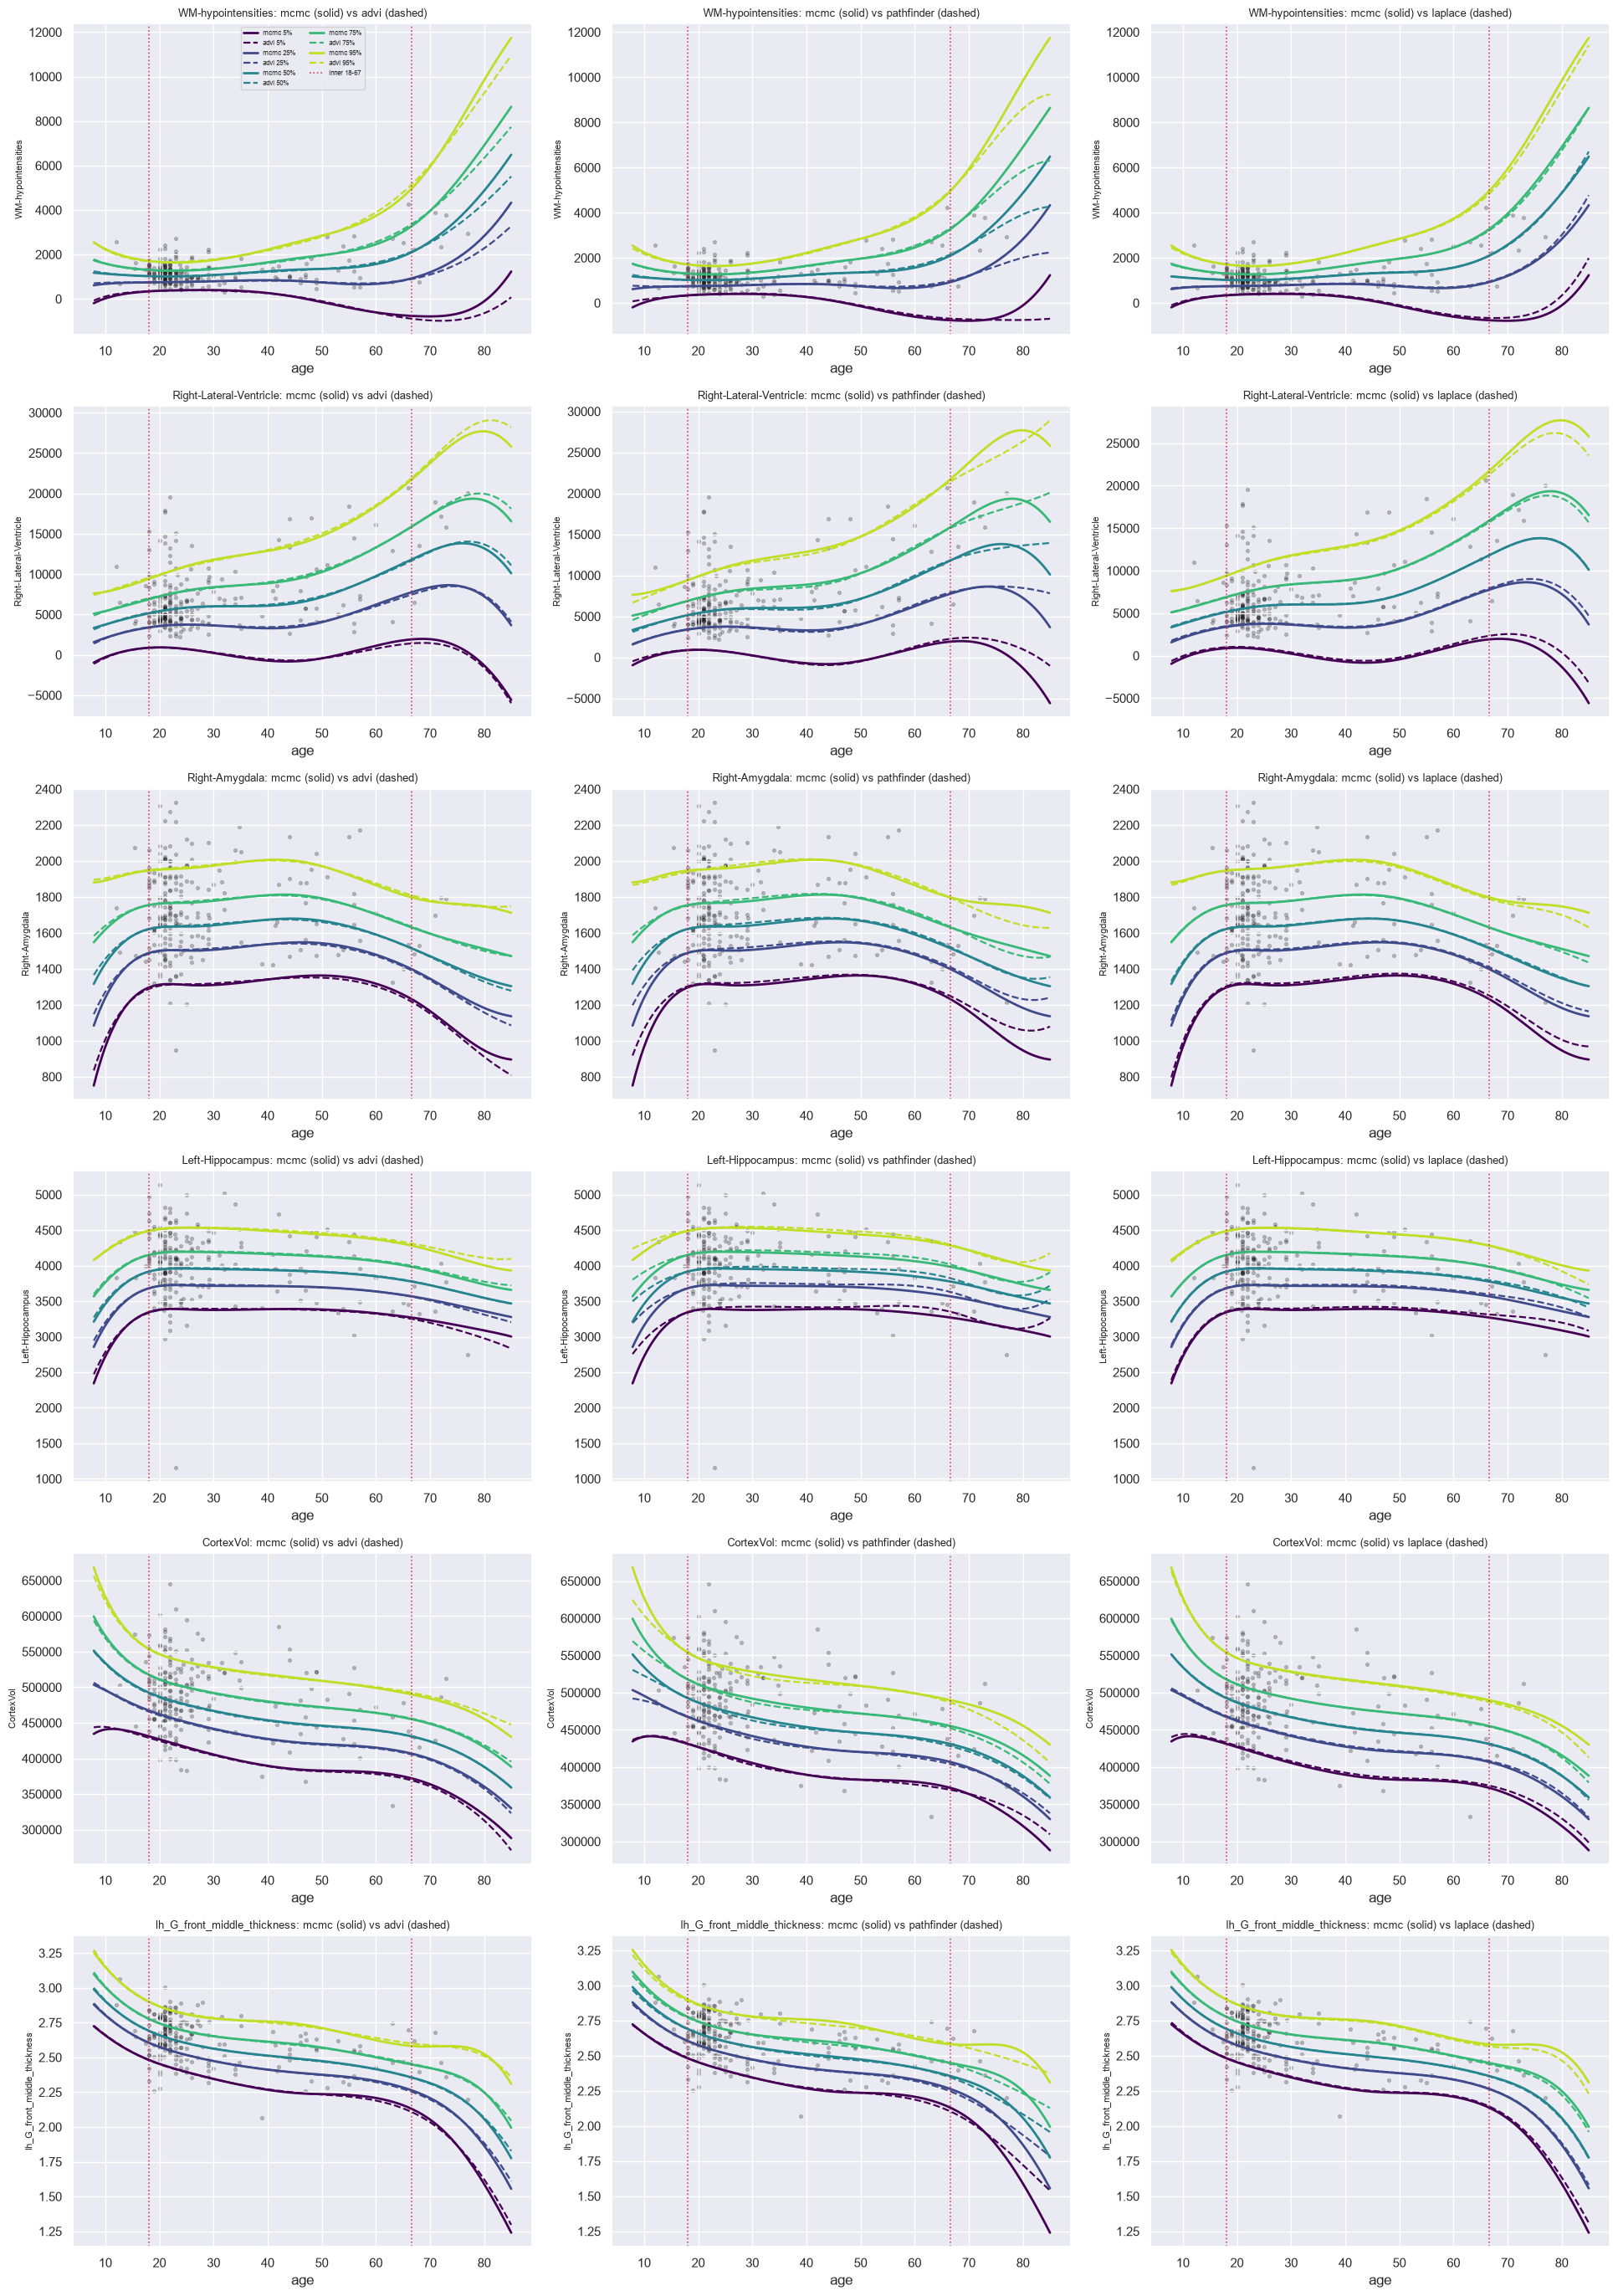

In [10]:
# Overlay for a direct visual diff: MCMC solid, approximation dashed.
fig, axes = plt.subplots(len(grid_rvs), len(others),
                         figsize=(6.5 * len(others), 4.6 * len(grid_rvs)),
                         squeeze=False)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(CENTILES)))

for r, rv in enumerate(grid_rvs):
    for c, method in enumerate(others):
        ax = axes[r][c]
        for i, cent in enumerate(CENTILES):
            ax.plot(grid_x, cref[i, :, r], color=colors[i], lw=2,
                    label=f"mcmc {int(cent * 100)}%")
            ax.plot(grid_x, cents[method][i, :, r], color=colors[i], lw=1.6,
                    ls="--", label=f"{method} {int(cent * 100)}%")
        ax.scatter(np.asarray(test.X.values)[:, 0],
                   np.asarray(test.Y.sel(response_vars=rv).values).ravel(),
                   s=8, color="black", alpha=0.2, zorder=0)
        ax.axvline(lo, color="crimson", ls=":", lw=1.2, alpha=0.8,
                   label=f"inner {lo:.0f}-{hi:.0f}")
        ax.axvline(hi, color="crimson", ls=":", lw=1.2, alpha=0.8)
        ax.set_title(f"{rv}: mcmc (solid) vs {method} (dashed)", fontsize=9)
        ax.set_xlabel(covariate)
        ax.set_ylabel(rv, fontsize=8)
        if r == 0 and c == 0:
            ax.legend(fontsize=6, ncol=2)

plt.tight_layout()
plt.show()

## 3. Posterior width vs MCMC

`sd_ratio` = approximate sd / MCMC sd, per parameter.

- **1.0** matches MCMC
- **< 1** underestimates uncertainty - the dangerous direction, since it
  inflates z-scores and invents outliers
- `mean_shift` is the gap between posterior means, in MCMC standard
  deviations. Above ~1 the parameter estimate itself is off, not just its
  uncertainty.

In [11]:
# One regression model per response variable, so sd_ratio is computed per model.
rows = []
for rv in RESPONSE_VARS:
    ref_idata = fits["mcmc"][rv].idata
    param_names = [v for v in ref_idata.posterior.data_vars if "_per_subject" not in v]
    for method in others:
        idata = fits[method][rv].idata
        for v in sorted(param_names):
            if v not in idata.posterior:
                continue
            a = idata.posterior[v].values
            b = ref_idata.posterior[v].values
            if a.size == 0 or b.size == 0 or b.std() == 0:
                continue
            rows.append({
                "response_var": rv,
                "method": method,
                "parameter": v,
                "sd_ratio": round(float(a.std() / b.std()), 3),
                "mean_shift (sd)": round(float(abs(a.mean() - b.mean()) / b.std()), 2),
            })

width_df = pd.DataFrame(rows)

summary = (width_df.groupby(["method", "parameter"])[["sd_ratio", "mean_shift (sd)"]]
           .mean().round(3).reset_index()
           .sort_values(["method", "sd_ratio"]))
print("mean sd_ratio over response variables (1.0 = matches MCMC):")
print(summary.to_string(index=False))
width_df.sort_values(["response_var", "method", "sd_ratio"]).reset_index(drop=True)

mean sd_ratio over response variables (1.0 = matches MCMC):
    method                           parameter  sd_ratio  mean_shift (sd)
      advi                     mu_intercept_mu     0.031            0.025
      advi                     intercept_sigma     0.135            0.263
      advi             site_sigma_intercept_mu     0.385            0.218
      advi                            slope_mu     0.388            0.062
      advi              sex_sigma_intercept_mu     0.503            0.505
      advi                         slope_sigma     0.808            0.058
      advi normalized_site_offset_intercept_mu     0.977            0.000
      advi            site_offset_intercept_mu     0.982            0.000
      advi             sex_offset_intercept_mu     1.010            0.000
      advi  normalized_sex_offset_intercept_mu     1.051            0.000
   laplace normalized_site_offset_intercept_mu     0.366            0.000
   laplace                            slope_mu     0

,response_var,method,parameter,sd_ratio,mean_shift (sd)
0,CortexVol,advi,mu_intercept_mu,0.029,0.02
1,CortexVol,advi,intercept_sigma,0.130,0.32
2,CortexVol,advi,sex_sigma_intercept_mu,0.206,0.69
3,CortexVol,advi,slope_mu,0.286,0.06
4,CortexVol,advi,site_sigma_intercept_mu,0.311,0.12
...,...,...,...,...,...
175,lh_G_front_middle_thickness,pathfinder,normalized_site_offset_intercept_mu,0.815,0.00
176,lh_G_front_middle_thickness,pathfinder,normalized_sex_offset_intercept_mu,0.837,0.00
177,lh_G_front_middle_thickness,pathfinder,sex_offset_intercept_mu,0.938,0.00
178,lh_G_front_middle_thickness,pathfinder,site_offset_intercept_mu,1.076,0.00
